/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_compressed.py:290: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  warn(bad_scalar_msg, SparseEfficiencyWarning)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


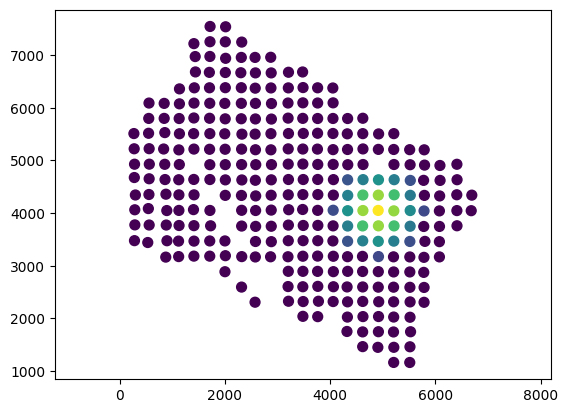

In [3]:
from scipy.sparse import csc_matrix, csr_matrix, issparse, hstack
from scipy import stats
import numpy as np
import pandas as pd
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import joblib
import squidpy as sq
import spatialdm as sdm
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from matplotlib_venn import venn2

# pure statistics for bivariate Moran's R
def Moran_R_std(spatial_W, by_trace=False):
    """Calculate standard deviation of Moran's R under the null distribution.
    """
    N = spatial_W.shape[0]

    if by_trace:
        W = spatial_W.copy()
        H = np.identity(N) - np.ones((N, N)) / N
        HWH = H.dot(W.dot(H))
        var = np.trace(HWH.dot(HWH)) * N**2 / (np.sum(W) * (N-1))**2
    else:
        if issparse(spatial_W):
            nm = N ** 2 * spatial_W.multiply(spatial_W.T).sum() \
                - 2 * N * (spatial_W.sum(0) @ spatial_W.sum(1)).sum() \
                + spatial_W.sum() ** 2
        else:
            nm = N ** 2 * (spatial_W * spatial_W.T).sum() \
                - 2 * N * (spatial_W.sum(1) * spatial_W.sum(0)).sum() \
                + spatial_W.sum() ** 2
        dm = N ** 2 * (N - 1) ** 2
        var = nm / dm

    return np.sqrt(var)


def Moran_R(X, Y, spatial_W, standardise=True, nproc=1):
    """Computing Moran's R for pairs of variables
    
    :param X: Variable 1, (n_sample, n_variables) or (n_sample, )
    :param Y: Variable 2, (n_sample, n_variables) or (n_sample, )
    :param spatial_W: spatial weight matrix, sparse or dense, (n_sample, n_sample)
    :param nproc: default to 1. Numpy may use more without much speedup.
    
    :return: (Moran's R, z score and p values)
    """
    if len(X.shape) < 2:
        X = X.reshape(-1, 1)
    if len(Y.shape) < 2:
        Y = Y.reshape(-1, 1)

    if standardise:
        X = (X - np.mean(X, axis=0, keepdims=True)) / np.std(X, axis=0, keepdims=True)
        Y = (Y - np.mean(Y, axis=0, keepdims=True)) / np.std(Y, axis=0, keepdims=True)

    # Consider to dense array for speedup (numpy's codes is optimised)
    if X.shape[0] <= 5000 and issparse(spatial_W):
        # Note, numpy may use unnessary too many threads
        # You may use threadpool.threadpool_limits() outside
        from threadpoolctl import threadpool_limits

        with threadpool_limits(limits=nproc, user_api='blas'):
            R_val = (spatial_W.A @ X * Y).sum(axis=0) / np.sum(spatial_W)
    else:
        # we assume it's sparse spatial_W when sample size > 5000
        R_val = (spatial_W @ X * Y).sum(axis=0) / np.sum(spatial_W)

    _R_std = Moran_R_std(spatial_W)
    R_z_score = R_val / _R_std
    R_p_val = stats.norm.sf(R_z_score)

    return R_val, R_z_score, R_p_val


cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/stnet/23209_C1/cell_ratio.csv").columns)[1:]]

from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/code/training/train_test_splits/stnet/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)

import joblib
import pandas as pd
import os

combinations = []
for i in range(len(cell_names)):
    for j in range(i+1, len(cell_names)):
        combinations.append((cell_names[i], cell_names[j]))
        
for case in test_slides:
    # os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case))
    
    save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/breast_cross_source/breast_cross_source_epoch100_lr1e-4_2hop_ensemble_Trans1layer_GNNoutput50_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
    pred_and_label = joblib.load(save_path)
    
    for slide in pred_and_label:
        # os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide))
        
        spot_coord = pred_and_label[slide]['coords']

        X = csr_matrix(pred_and_label[slide]['cell_abundance_labels'])
        adata = ad.AnnData(X, obsm={"spatial": spot_coord})
        adata.var_names = cell_names
        
        sdm.weight_matrix(adata, l=500, cutoff=0.2, single_cell=False, n_neighbors=160)
        plt.scatter(list(adata.obsm['spatial'][:,0]), list(adata.obsm['spatial'][:,1]),
            c=adata.obsp['weight'].A[50], s=50.0)
        plt.axis('equal')
        plt.show()
        break
    break